# SED Poisson Workflow

This notebook reproduces the per-bin SED Poisson workflow and validates the Poisson approximation against direct log-likelihood evaluation.

In [12]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

%run ../pylib/tools dark
from importlib import reload
from astropy.coordinates import SkyCoord
from like3 import pixel_table as pixel_table_mod; reload(pixel_table_mod)
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
from like3 import sedfuns as sedfuns_mod; reload(sedfuns_mod)
from like3 import main as main_mod; reload(main_mod)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PixelTable = pixel_table_mod.PixelTable
SourceModel = sourcelist_mod.SourceModel
FermiFit = main_mod.FermiFit

In [13]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog(
    'v40',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)
selected_name = roi_sources.source_names[0]
pt = PixelTable('../files/kerr/toby_v4.fits', source_model=roi_sources)
# Running this notebook from docs/ requires an explicit PSF table path.
pt.set_psf(table_path='../files/loc')
ff = FermiFit(pt)
selected_name

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
Loaded pixel table from "../files/kerr/toby_v4.fits":
            42 bands Band(0, np.int64(4)): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, np.int64(11)): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: no PSF entries loaded from 'files/loc'


[Errno 2] No such file or directory: 'files/loc'


set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from '../files/loc'


np.str_('FL16Y J0633.9+1746')

In [14]:
sedp = ff.get_sed_poisson_table(source_name=selected_name, tol=0.2)
display(sedp[['elow', 'ehigh', 'flux', 'lflux', 'uflux', 'ts', 'maxdev']])

,elow,ehigh,flux,lflux,uflux,ts,maxdev
energy,,,,,,,
133,100.000000,177.827941,183.063333,182.141809,183.987226,91679.498269,0.001694
237,177.827941,316.227766,330.565944,329.412033,331.722329,309923.002318,0.000397
421,316.227766,562.341325,NaN,NaN,NaN,NaN,NaN
749,562.341325,1000.000000,732.068675,730.388376,733.751372,764468.584772,0.001301
1333,1000.000000,1778.279410,NaN,NaN,NaN,NaN,NaN
2371,1778.279410,3162.277660,853.051667,850.603882,855.503844,502715.971350,0.000691
4216,3162.277660,5623.413252,576.768299,574.199030,579.344731,208049.343418,0.000503
7498,5623.413252,10000.000000,259.193513,256.968596,261.430103,49266.637641,0.000753
13335,10000.000000,17782.794100,69.740087,68.219899,71.282660,23077.152302,0.000356


/tmp/ipykernel_151018/1516405774.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


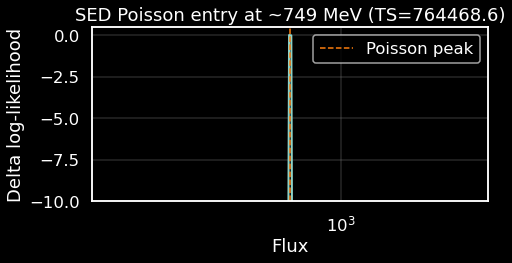

In [7]:
valid = sedp[sedp.poiss.notna()]
if len(valid) == 0:
    print('No valid Poisson entries found in SED table.')
else:
    row = valid.sort_values('ts', ascending=False).iloc[0]
    p = row.poiss

    f0 = max(float(row.flux), 1e-20)
    f_lo = max(float(row.lflux), 1e-20) if np.isfinite(row.lflux) else f0 / 3.0
    f_hi = float(row.uflux) if np.isfinite(row.uflux) else f0 * 3.0
    lo = max(min(f_lo, f0 / 3.0), 1e-20)
    hi = max(f_hi, f0 * 3.0, lo * 1.5)

    flux_grid = np.geomspace(lo, hi, 160)
    dll = p(flux_grid)
    dll = dll - np.max(dll)

    plt.figure(figsize=(7, 4))
    plt.plot(flux_grid, dll, lw=2)
    plt.axvline(float(row.flux), color='tab:orange', ls='--', lw=1.5, label='Poisson peak')
    plt.xscale('log')
    plt.ylim(-10, 0.5)
    plt.xlabel('Flux')
    plt.ylabel('Delta log-likelihood')
    plt.title(f'SED Poisson entry at ~{int(row.name)} MeV (TS={row.ts:.1f})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
valid = sedp[sedp.poiss.notna()]
if len(valid) == 0:
    print('No valid Poisson entries found in SED table.')
else:
    row = valid.sort_values('ts', ascending=False).iloc[0]
    p = row.poiss
    elow, ehigh = float(row.elow), float(row.ehigh)

    chosen = [
        b for b in ff.pixel_table.values()
        if float(b.e0) >= elow and float(b.e1) <= ehigh
    ]

    f_peak = max(float(row.flux), 1e-20)
    f_lo = float(row.lflux) if np.isfinite(row.lflux) and row.lflux > 0 else f_peak * 0.85
    f_hi = float(row.uflux) if np.isfinite(row.uflux) and row.uflux > 0 else f_peak * 1.15
    flux_pts = np.array(sorted({max(f_lo, 1e-20), f_peak, max(f_hi, 1e-20)}), dtype=float)

    saved_keys = ff.pixel_table._selected
    efv = ff.energy_flux_view(selected_name, bound=-20)
    try:
        ff.pixel_table.select(keys=[b.key for b in chosen])
        efv.set_energy(np.sqrt(elow * ehigh))

        ll_direct = np.array([float(efv(f)) for f in flux_pts], dtype=float)
        ll_poiss = np.array([float(p(f)) for f in flux_pts], dtype=float)

        d_direct = ll_direct - ll_direct.max()
        d_poiss = ll_poiss - ll_poiss.max()
        d_diff = d_direct - d_poiss

        cmp = pd.DataFrame({
            'flux': flux_pts,
            'direct_dll': d_direct,
            'poiss_dll': d_poiss,
            'difference': d_diff,
        })
        display(cmp)
        print(f"Max |difference| = {np.max(np.abs(d_diff)):.3e} for bin ~{int(row.name)} MeV")
    finally:
        ff.pixel_table.select(keys=saved_keys)
        if hasattr(efv, 'restore'):
            efv.restore()

,flux,direct_dll,poiss_dll,difference
0,730.388376,-0.502139,-0.5,-0.002139
1,732.068675,0.000000,0.0,0.000000
2,733.751372,-0.497858,-0.5,0.002142


Max |difference| = 2.142e-03 for bin ~749 MeV


In [ ]:
# Test: FermiFit.plot_sed_with_band_points
src = ff.source_model.find_source(selected_name)
ax = ff.plot_sed_with_band_points(src, update=True, tol=0.2)

# Basic API/plot-content checks
assert ax is not None, 'Expected a matplotlib Axes return value.'
assert hasattr(src, 'sed_poisson_table') and src.sed_poisson_table is not None, \
    'Expected source.sed_poisson_table to be available after plotting.'

markers = [line.get_marker() for line in ax.lines]
has_model_line = any(m in (None, 'None', '') for m in markers)
has_band_markers = any(m == 'o' for m in markers)

assert has_model_line, 'Expected a model SED curve line on the axes.'
assert has_band_markers, 'Expected per-band errorbar markers on the axes.'

print('PASS: plot_sed_with_band_points produced model curve + per-band points.')

In [16]:
# Test: FermiFit.sed_poisson_delta_decomposition
src = ff.source_model.find_source(selected_name)
out = ff.sed_poisson_delta_decomposition(src, alpha=1.05, update=True, tol=0.2)

# Structural checks
required = {'per_band', 'sum_poisson_delta', 'all_band_delta', 'difference', 'alpha', 'source_name'}
assert required.issubset(out.keys()), f"Missing keys: {sorted(required - set(out.keys()))}"

per_band = out['per_band']
assert isinstance(per_band, pd.DataFrame), 'Expected per_band to be a pandas DataFrame.'
assert len(per_band) > 0, 'Expected at least one per-band entry.'
assert {'energy', 'flux_ref', 'flux_test', 'dll_poiss'}.issubset(per_band.columns), 'Missing per_band columns.'

# Numeric checks
assert np.isfinite(float(out['sum_poisson_delta'])), 'sum_poisson_delta must be finite.'
assert np.isfinite(float(out['all_band_delta'])), 'all_band_delta must be finite.'
assert np.isfinite(float(out['difference'])), 'difference must be finite.'
assert np.isclose(float(out['alpha']), 1.05), 'alpha mismatch.'
assert out['source_name'] == src.name, 'source_name mismatch.'

print('PASS: sed_poisson_delta_decomposition returned expected structure and finite values.')

PASS: sed_poisson_delta_decomposition returned expected structure and finite values.
